# Rozpoznawanie cyfr pisanych odręcznie (MNIST)

## Opis projektu
Projekt dotyczy klasyfikacji cyfr pisanych odręcznie (0-9) na podstawie zbioru danych MNIST.
W ramach projektu przeprowadzono eksperymenty z wykorzystaniem:
- Sieci konwolucyjnej (CNN) zbudowanej w Keras/TensorFlow bez augmentacji danych (Gałąź 1)
- Sieci konwolucyjnej (CNN) zbudowanej w Keras/TensorFlow z augmentacją danych (Gałąź 2)
- Własnej implementacji CNN napisanej od zera w NumPy (Gałąź 3)

### Autorzy
- Bartosz Majewski

### Technologie
- Python 3.13
- TensorFlow / Keras
- NumPy, Pandas, Matplotlib, Seaborn
- scikit-learn
- Własna biblioteka `my_cnn` (implementacja CNN od zera)

---
# 1. Analiza zbioru treningowego

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, losses
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# Wczytanie danych
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Podstawowe informacje o zbiorze MNIST")
print(f"Zbiór treningowy:  {x_train.shape[0]:>10,} obrazów")
print(f"Zbiór testowy:     {x_test.shape[0]:>10,} obrazów")
print(f"Łączna liczba:     {x_train.shape[0] + x_test.shape[0]:>10,} obrazów")
print(f"\nWymiary obrazu:    {x_train.shape[1]} x {x_train.shape[2]} pikseli (skala szarości)")
print(f"Liczba cech (pikseli): {x_train.shape[1] * x_train.shape[2]}")
print(f"Zakres wartości pikseli: [{x_train.min()}, {x_train.max()}]")
print(f"Typ danych: {x_train.dtype}")
print(f"Liczba klas: {len(np.unique(y_train))} (cyfry 0-9)")

Podstawowe informacje o zbiorze MNIST
Zbiór treningowy:      60,000 obrazów
Zbiór testowy:         10,000 obrazów
Łączna liczba:         70,000 obrazów

Wymiary obrazu:    28 x 28 pikseli (skala szarości)
Liczba cech (pikseli): 784
Zakres wartości pikseli: [0, 255]
Typ danych: uint8
Liczba klas: 10 (cyfry 0-9)


### 1.1 Rozkład klas (zbalansowanie zbioru)

In [3]:
# Rozkład klas w zbiorze treningowym
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

df_balance = pd.DataFrame({
    'Cyfra': unique_train,
    'Treningowy (n)': counts_train,
    'Treningowy (%)': np.round(counts_train / len(y_train) * 100, 2),
    'Testowy (n)': counts_test,
    'Testowy (%)': np.round(counts_test / len(y_test) * 100, 2),
})
print("Rozkład klas:")
display(df_balance)

print(f"\nStosunek max/min w zbiorze treningowym: {counts_train.max() / counts_train.min():.2f}")
print(f"Odchylenie standardowe udziału procentowego: {np.std(counts_train / len(y_train) * 100):.2f}%")

Rozkład klas:


,Cyfra,Treningowy (n),Treningowy (%),Testowy (n),Testowy (%)
0,0,5923,9.87,980,9.80
1,1,6742,11.24,1135,11.35
2,2,5958,9.93,1032,10.32
3,3,6131,10.22,1010,10.10
4,4,5842,9.74,982,9.82
5,5,5421,9.04,892,8.92
6,6,5918,9.86,958,9.58
7,7,6265,10.44,1028,10.28
8,8,5851,9.75,974,9.74
9,9,5949,9.92,1009,10.09



Stosunek max/min w zbiorze treningowym: 1.24
Odchylenie standardowe udziału procentowego: 0.54%


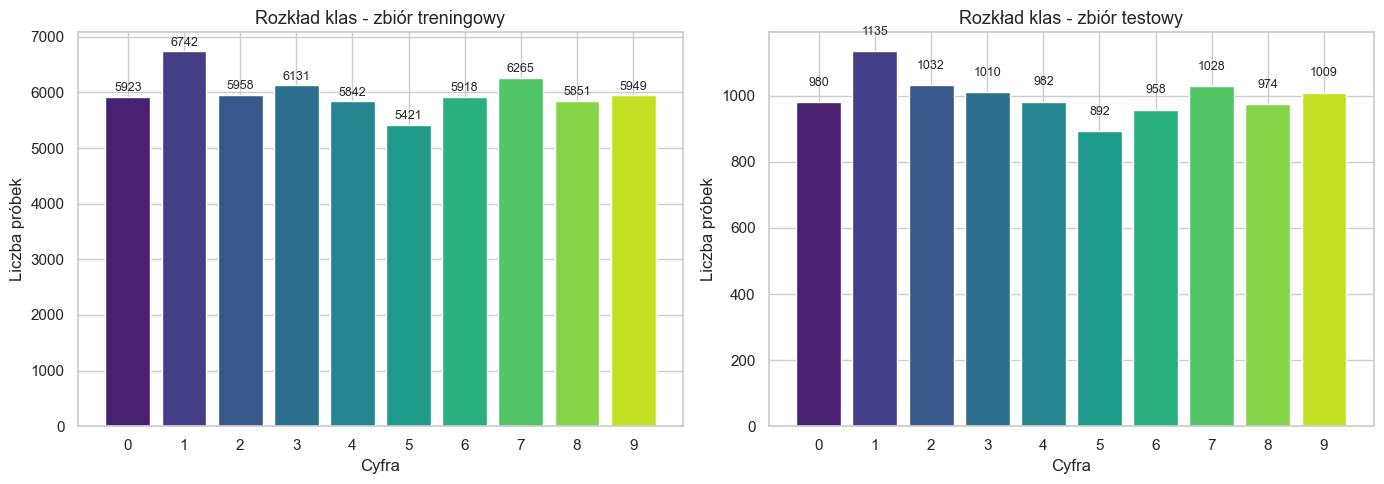

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('viridis', 10)

axes[0].bar(unique_train, counts_train, color=colors)
axes[0].set_title('Rozkład klas - zbiór treningowy', fontsize=13)
axes[0].set_xlabel('Cyfra')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_xticks(range(10))
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

axes[1].bar(unique_test, counts_test, color=colors)
axes[1].set_title('Rozkład klas - zbiór testowy', fontsize=13)
axes[1].set_xlabel('Cyfra')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_xticks(range(10))
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.2 Przykładowe obrazy ze zbioru

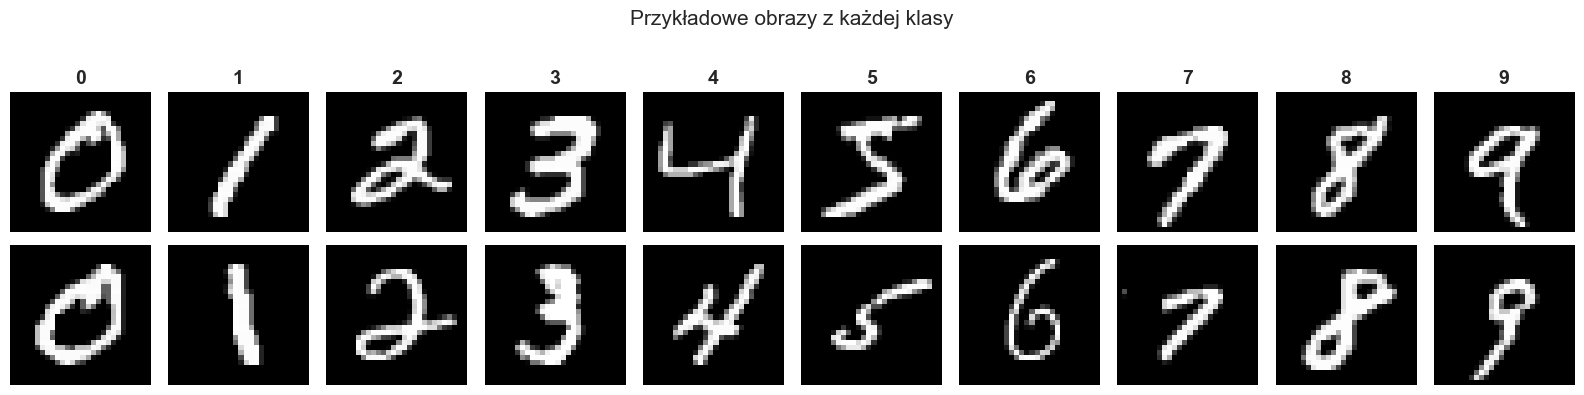

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    idxs = np.where(y_train == digit)[0]
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(x_train[idxs[row]], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=14, fontweight='bold')
fig.suptitle('Przykładowe obrazy z każdej klasy', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Statystyki pikseli

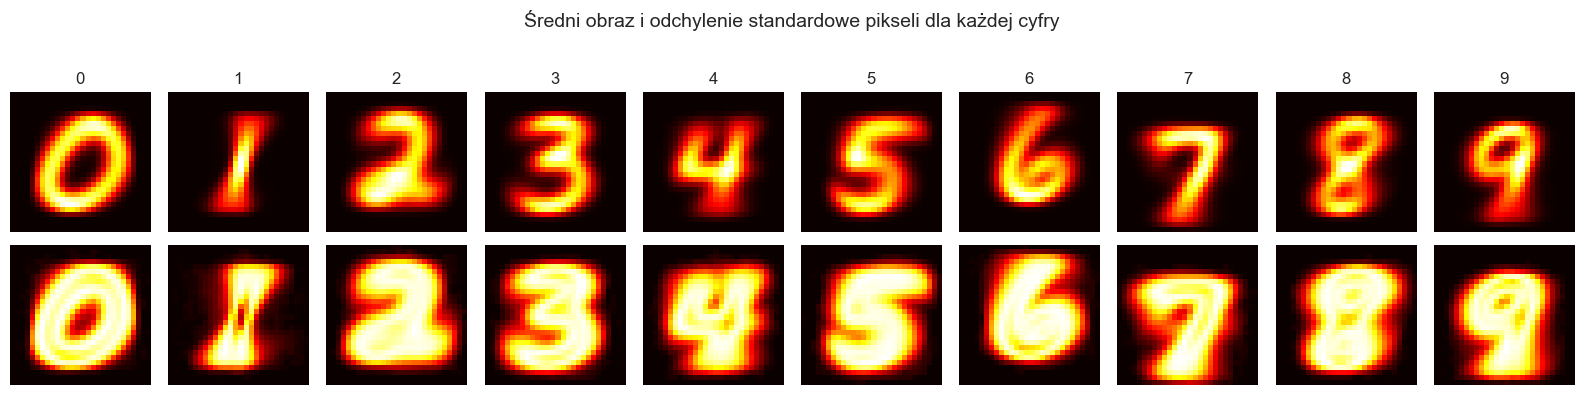

In [6]:
# Średni obraz i odchylenie standardowe pikseli
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    digit_imgs = x_train[y_train == digit]
    mean_img = digit_imgs.mean(axis=0)
    std_img = digit_imgs.std(axis=0)
    
    axes[0, digit].imshow(mean_img, cmap='hot')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(str(digit), fontsize=12)
    
    axes[1, digit].imshow(std_img, cmap='hot')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Średnia', fontsize=11)
axes[1, 0].set_ylabel('Odch. std.', fontsize=11)
fig.suptitle('Średni obraz i odchylenie standardowe pikseli dla każdej cyfry', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

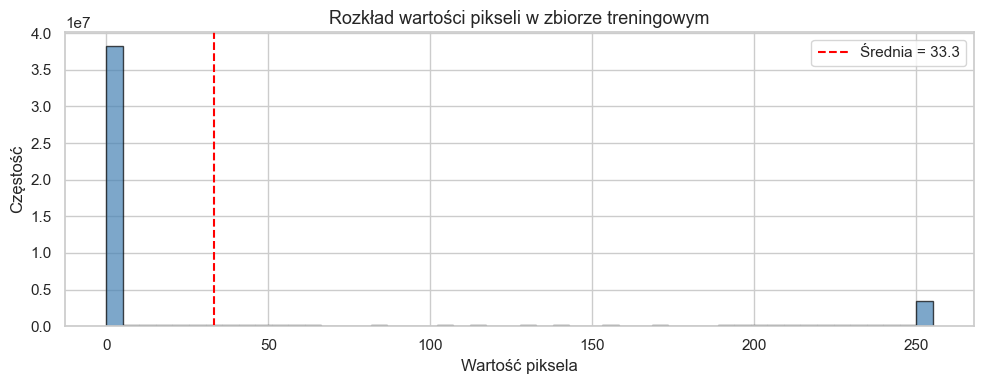

Procent pikseli niezerowych: 19.1%
Procent pikseli zerowych (tło): 80.9%


In [7]:
# Rozkład wartości pikseli w zbiorze treningowym
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(x_train.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Rozkład wartości pikseli w zbiorze treningowym', fontsize=13)
ax.set_xlabel('Wartość piksela')
ax.set_ylabel('Częstość')
ax.axvline(x=x_train.flatten().mean(), color='red', linestyle='--', label=f'Średnia = {x_train.flatten().mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

nonzero_pct = (x_train > 0).sum() / x_train.size * 100
print(f"Procent pikseli niezerowych: {nonzero_pct:.1f}%")
print(f"Procent pikseli zerowych (tło): {100 - nonzero_pct:.1f}%")

---
# 2. Analiza istotności cech (pikseli)

W przypadku obrazów piksele stanowią cechy wejściowe modelu. Zamiast klasycznych metod feature selection (jak SelectKBest),
które zakładają cechy tabelaryczne, stosujemy podejście oparte na analizie wariancji pikseli.

### Metoda: Analiza wariancji pikseli między klasami
Obliczamy średni obraz dla każdej klasy, a następnie wariancję tych średnich obrazów po klasach.
Piksele o wysokiej wariancji międzyklasowej to te, które najbardziej różnicują cyfry - są więc najistotniejszymi cechami.
Piksele o niskiej wariancji (np. rogi obrazu) nie wnoszą informacji do klasyfikacji.

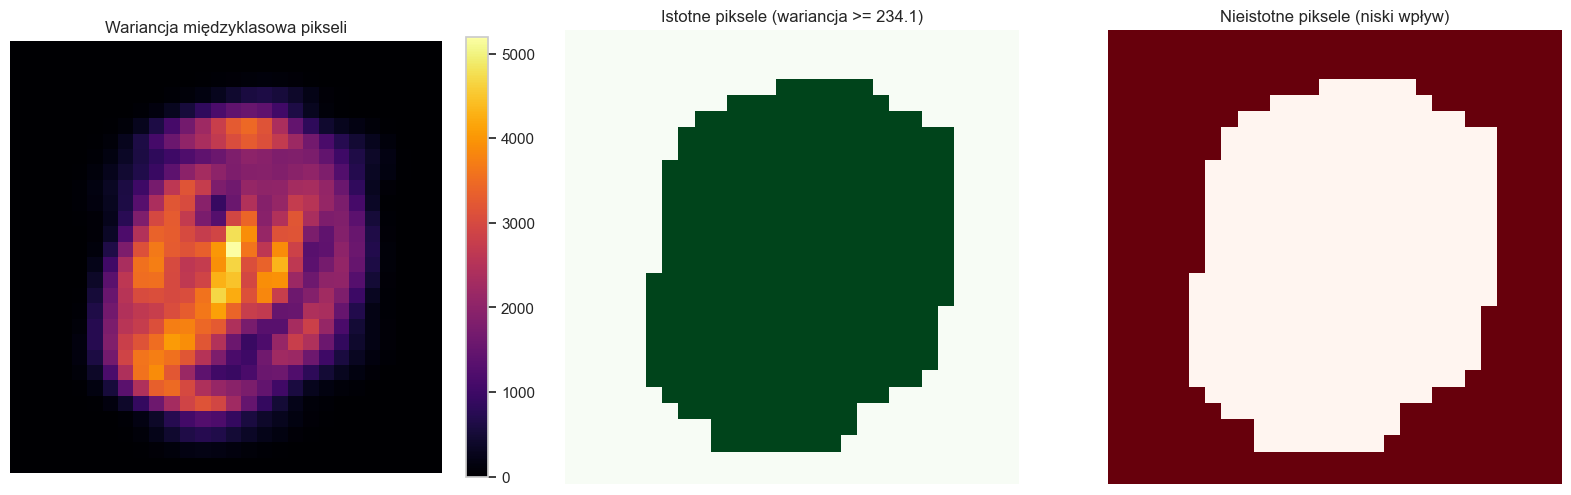

Liczba istotnych pikseli: 359 / 784 (45.8%)
Liczba nieistotnych pikseli: 425 / 784 (54.2%)


In [8]:
# Obliczenie średnich obrazów dla każdej klasy
class_means = np.array([x_train[y_train == d].mean(axis=0) for d in range(10)])

# Wariancja międzyklasowa - dla każdego piksela liczymy wariancję po 10 średnich
inter_class_variance = class_means.var(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mapa wariancji
im0 = axes[0].imshow(inter_class_variance, cmap='inferno')
axes[0].set_title('Wariancja międzyklasowa pikseli', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Maska: piksele powyżej mediany wariancji
threshold = np.median(inter_class_variance[inter_class_variance > 0])
important_mask = (inter_class_variance >= threshold).astype(float)
axes[1].imshow(important_mask, cmap='Greens')
axes[1].set_title(f'Istotne piksele (wariancja >= {threshold:.1f})', fontsize=12)
axes[1].axis('off')

# Nieistotne piksele (rogi, krawędzie)
unimportant_mask = (inter_class_variance < threshold).astype(float)
axes[2].imshow(unimportant_mask, cmap='Reds')
axes[2].set_title('Nieistotne piksele (niski wpływ)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

n_important = int(important_mask.sum())
n_total = 28 * 28
print(f"Liczba istotnych pikseli: {n_important} / {n_total} ({n_important/n_total*100:.1f}%)")
print(f"Liczba nieistotnych pikseli: {n_total - n_important} / {n_total} ({(n_total - n_important)/n_total*100:.1f}%)")

In [9]:
# Ranking pikseli wg wariancji międzyklasowej
variance_flat = inter_class_variance.flatten()
pixel_ranking = np.argsort(variance_flat)[::-1]

top_n = 20
print(f"Top {top_n} najistotniejszych pikseli (indeks, pozycja wiersz x kolumna, wariancja):")
print("-" * 55)
for rank, idx in enumerate(pixel_ranking[:top_n], 1):
    row, col = divmod(idx, 28)
    print(f"  {rank:>2}. Piksel [{row:>2}, {col:>2}]  (indeks {idx:>3})  wariancja = {variance_flat[idx]:.2f}")

Top 20 najistotniejszych pikseli (indeks, pozycja wiersz x kolumna, wariancja):
-------------------------------------------------------
   1. Piksel [13, 14]  (indeks 378)  wariancja = 5200.81
   2. Piksel [12, 14]  (indeks 350)  wariancja = 4776.06
   3. Piksel [16, 13]  (indeks 461)  wariancja = 4678.83
   4. Piksel [14, 14]  (indeks 406)  wariancja = 4660.99
   5. Piksel [15, 14]  (indeks 434)  wariancja = 4488.41
   6. Piksel [14, 17]  (indeks 409)  wariancja = 4331.34
   7. Piksel [15, 13]  (indeks 433)  wariancja = 4298.57
   8. Piksel [16, 14]  (indeks 462)  wariancja = 4229.58
   9. Piksel [17, 13]  (indeks 489)  wariancja = 4122.39
  10. Piksel [19, 10]  (indeks 542)  wariancja = 4047.98
  11. Piksel [13, 13]  (indeks 377)  wariancja = 4020.39
  12. Piksel [15, 17]  (indeks 437)  wariancja = 3946.40
  13. Piksel [14, 13]  (indeks 405)  wariancja = 3923.16
  14. Piksel [19, 11]  (indeks 543)  wariancja = 3920.60
  15. Piksel [15, 16]  (indeks 436)  wariancja = 3911.72
  16. Pik

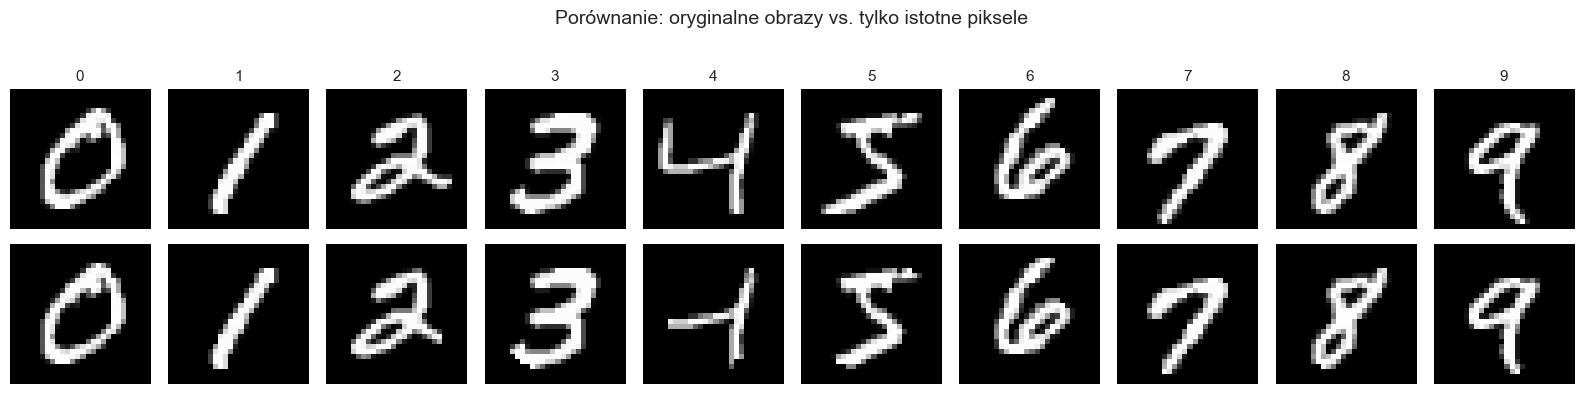

In [10]:
# Wizualizacja: efekt usunięcia nieistotnych pikseli
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    original = x_train[idx]
    masked = original * important_mask
    
    axes[0, digit].imshow(original, cmap='gray')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(str(digit), fontsize=11)
    
    axes[1, digit].imshow(masked, cmap='gray')
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel('Oryginał', fontsize=11)
axes[1, 0].set_ylabel('Po masce', fontsize=11)
fig.suptitle('Porównanie: oryginalne obrazy vs. tylko istotne piksele', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### 3. Augmentacja Danych

Aby uodpornić model na niedoskonałości pisma ręcznego oraz zwiększyć ogólną zdolność generalizacji sieci, wprowadzono dwie formy augmentacji danych treningowych:
1. **Obrót**: Każdy obraz jest obracany o określony kąt z zakresu od -20° do 20° z krokiem co 5°.
2. **Szum Gaussowski**: Do obrazów (zarówno oryginalnych, jak i obróconych) dodawany jest szum z rozkładu normalnego (std=20), imitujący niedokładności skanowania lub zabrudzenia tła.

Zastosowana logika generuje nowe przypadki dla każdego obrazka wejściowego:
- Dodanie samego szumu gaussowskiego do oryginału.
- Wygenerowanie wariantów obróconych.
- Dodanie szumu do wygenerowanych wariantów obróconych.

Łącznie na każdy obraz powstaje: 1 (oryginał) + 1 (szum) + 8 (obroty) + 8 (obroty+szum) = 18 wariantów

Razem: 60 000 x 18 = 1 080 000 rekordów.

### 3.1 Przykłady augmentacji dla każdej cyfry

Poniższa wizualizacja pokazuje przykładowe modyfikacje dla każdej cyfry (0-9) ze zbioru danych. Prezentujemy kolejno:
1. Obraz oryginalny
2. Obraz obrócony o 20 stopni
3. Obraz z dodanym szumem gaussowskim (std=20)
4. Połączenie obu transformacji (obrót o 20 stopni + szum)

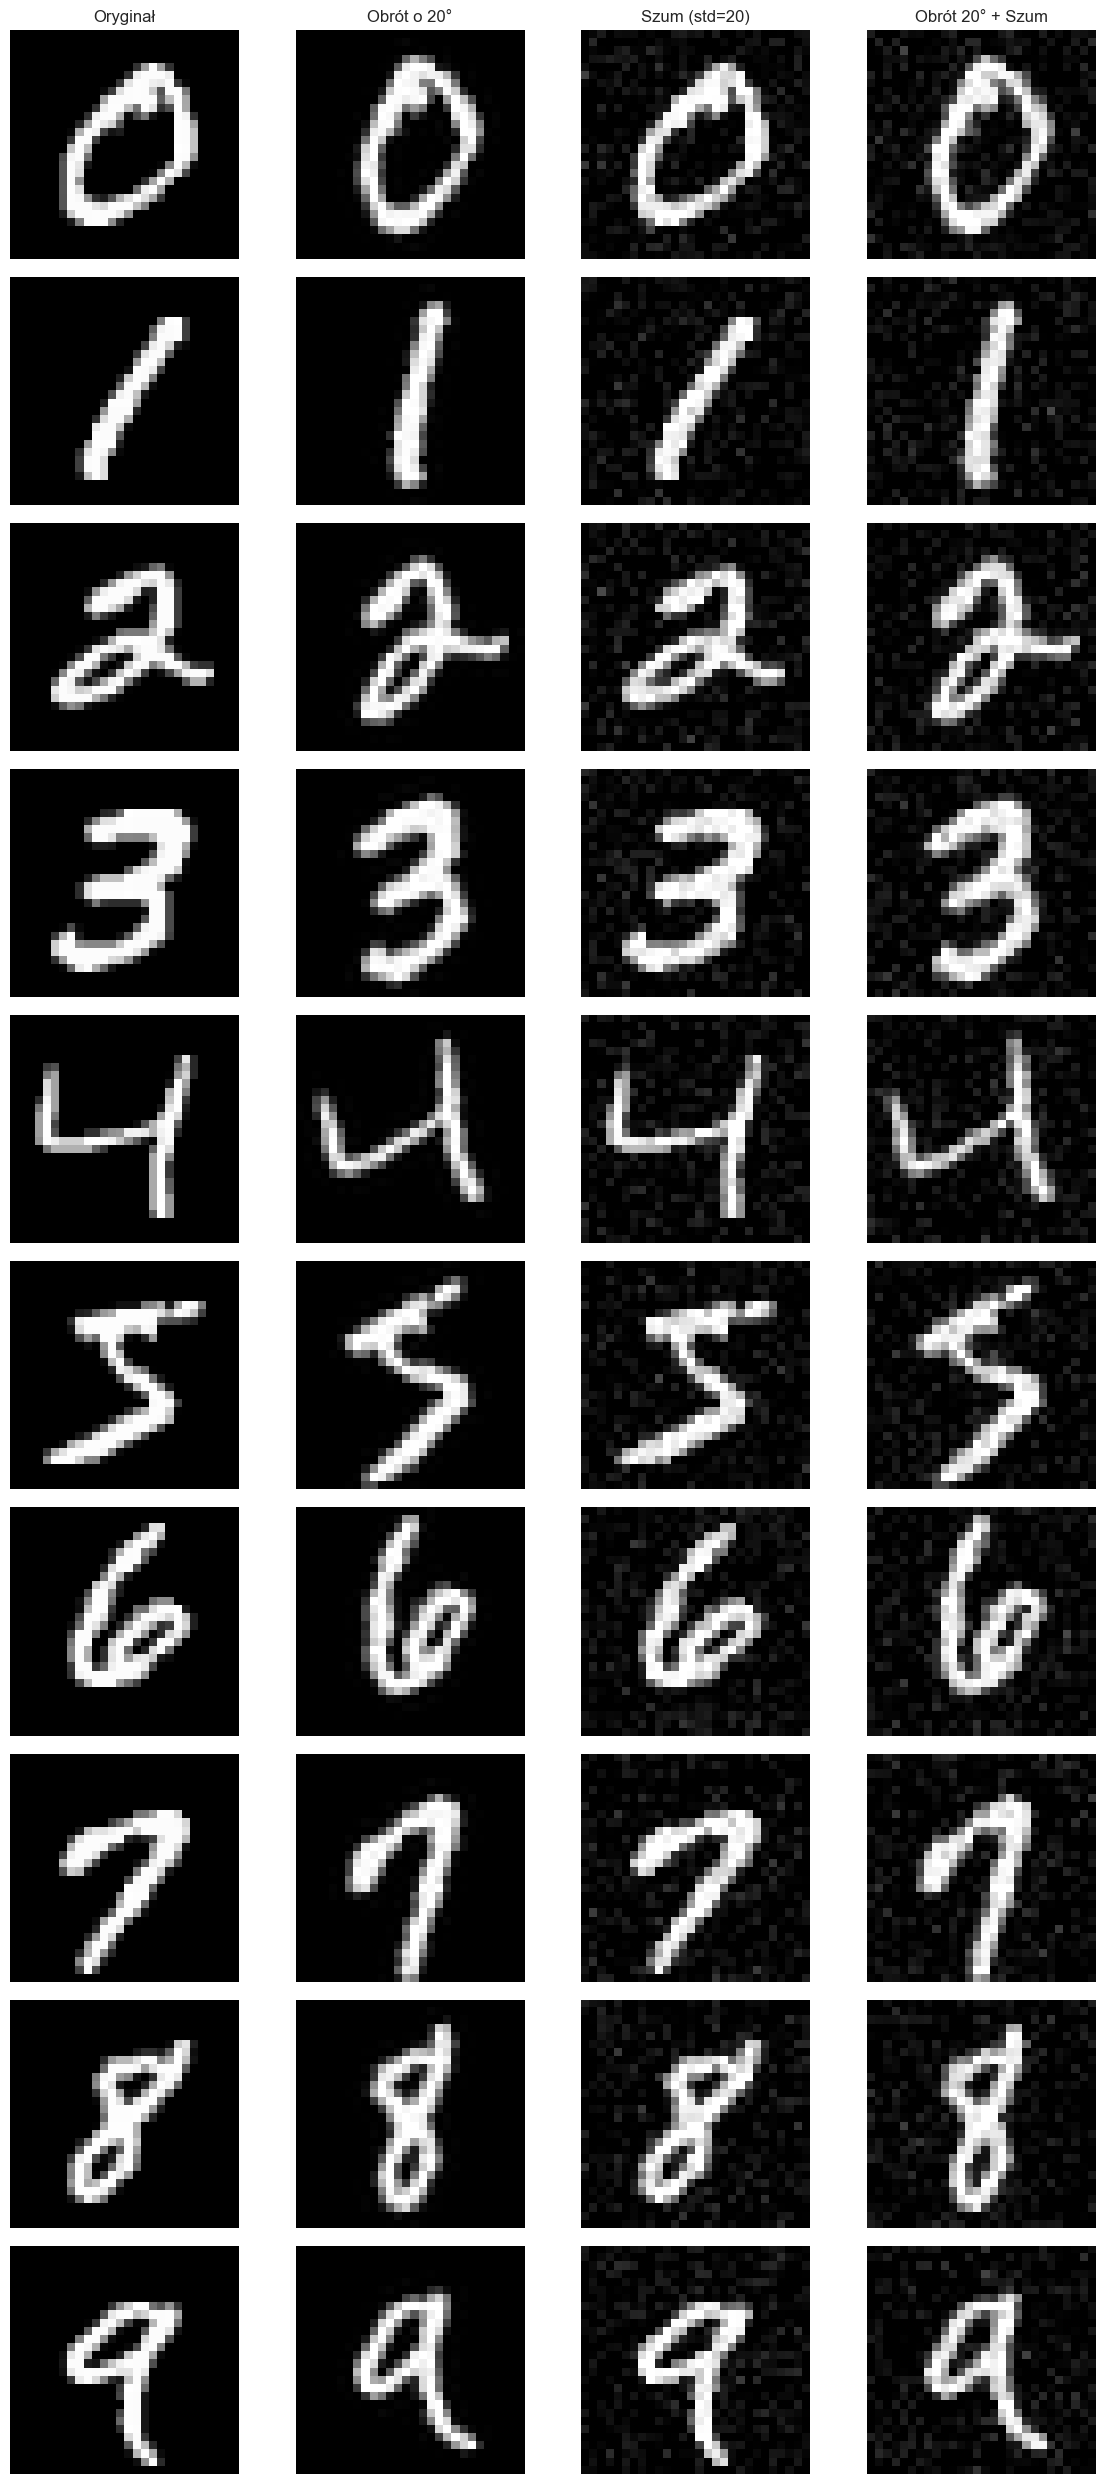

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Przykładowe wizualizacje transformacji
NOISE_STD = 20.0

fig, axes = plt.subplots(10, 4, figsize=(12, 25))

samples = [x_train[y_train == i][0] for i in range(10)]

for i, img in enumerate(samples):
    # 1. Oryginał
    axes[i, 0].imshow(img, cmap='gray')
    if i == 0:
        axes[i, 0].set_title("Oryginał")
    axes[i, 0].axis('off')
    
    # 2. Obrót
    img_rot = rotate(img, 20, axes=(0,1), reshape=False, mode='constant', cval=0.0)
    axes[i, 1].imshow(img_rot, cmap='gray')
    if i == 0:
        axes[i, 1].set_title("Obrót o 20°")
    axes[i, 1].axis('off')
    
    # 3. Szum
    noise = np.random.normal(loc=0.0, scale=NOISE_STD, size=img.shape)
    img_noised = img + noise
    img_noised = np.clip(img_noised, 0, 255).astype(np.uint8)
    axes[i, 2].imshow(img_noised, cmap='gray')
    if i == 0:
        axes[i, 2].set_title(f"Szum (std={int(NOISE_STD)})")
    axes[i, 2].axis('off')
    
    # 4. Obrót + Szum
    noise_rot = np.random.normal(loc=0.0, scale=NOISE_STD, size=img_rot.shape)
    img_rot_noised = img_rot + noise_rot
    img_rot_noised = np.clip(img_rot_noised, 0, 255).astype(np.uint8)
    axes[i, 3].imshow(img_rot_noised, cmap='gray')
    if i == 0:
        axes[i, 3].set_title("Obrót 20° + Szum")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

---
# 4. Eksperymenty

Poniżej przedstawiono 3 gałęzie eksperymentów.

**Mierniki jakościowe:**
- **Accuracy** - ogólna dokładność klasyfikacji
- **Precision** - precyzja uśredniona po klasach
- **Recall** - czułość uśredniona po klasach
- **F1-score** - średnia harmoniczna precision i recall

## 4.1 Gałąź 1 - Keras CNN bez augmentacji

Zbiór treningowy: **60 000 obrazów** (oryginalny MNIST, bez augmentacji).

Kod treningowy: `notebooks/recognition_without_augmentation.ipynb`


## 4.2 Gałąź 2 - Keras CNN z augmentacją danych

Zbiór treningowy: **1 080 000 obrazów** (MNIST + augmentacja: rotacje + szum gaussowski).

Kod treningowy: `notebooks/recognition_with_augmentation.ipynb`


## 4.3 Gałąź 3 - Własna implementacja CNN (my_cnn)

Sieć napisana od zera w NumPy z własną implementacją:
- Warstw: `Convolution2D`, `MaxPooling2D`, `Dense`, `Flatten`, `Rescaling`, `Input`
- Funkcji aktywacji: `ReLU`, `Softmax`
- Funkcji straty: `CrossEntropy`
- Optymalizatora: `SGD`

Zbiór treningowy: **60 000 obrazów** (oryginalny MNIST).

Kod treningowy: `notebooks/mycnn.ipynb`



---
# 5. Porównanie wyników między gałęziami

Zestawienie najlepszych wyników z każdej gałęzi eksperymentów.
<table border="1">
  <thead>
    <tr>
      <th></th>
      <th>Loss</th>
      <th>Accuracy</th>
      <th>Precision (macro avg)</th>
      <th>Recall (macro avg)</th>
      <th>F1-score (macro avg)</th>
      <th>Zbiór</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Bez augmentacji</td>
      <td>0.03103913925588131</td>
      <td>98.89</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>60 000</td>
    </tr>
    <tr>
      <td>Z augmentacja</td>
      <td>0.018817894160747528</td>
      <td>99.41</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>0.99</td>
      <td>1 080 000</td>
    </tr>
    <tr>
      <td>Własny CNN</td>
      <td>0.14799622432457485</td>
      <td>95.14</td>
      <td>0.95</td>
      <td>0.95</td>
      <td>0.95</td>
      <td>60 000</td>
    </tr>
  </tbody>
</table>

---
# 6. Obserwacje (interpretacja wyników)

## 6.1 Jak zmiana liczby filtrów Conv wpływa na accuracy?
Zwiększenie liczby filtrów w warstwach konwolucyjnych pozwala sieci na wyodrębnienie większej liczby różnorodnych cech (od prostych krawędzi do złożonych kształtów). Wyniki pokazują, że zwiększenie liczby filtrów (np. do 32 i 64) znacząco poprawia pojemność modelu, co przekłada się na widoczny wzrost dokładności (accuracy) oraz spadek błędu, o ile model nie popada w przeuczenie.

## 6.2 Jak zmiana dropout wpływa na overfitting?
Zastosowanie regularyzacji Dropout jest wysoce skuteczne w zapobieganiu przeuczeniu. W modelach bez dropoutu zaobserwowano spadek błędu treningowego przy wzroście błędu testowego, co wskazywało na zapamiętywanie danych. Wprowadzenie dropoutu na poziomie 0.3-0.5 zmusza sieć do nauki bardziej uniwersalnych i odpornych cech, co domyka lukę między skutecznością na zbiorze treningowym i testowym.

## 6.3 Jak augmentacja danych wpłynęła na wyniki?
Augmentacja znacząco wpłynęła na stabilność i wyniki generalizacyjne modelu. Poszerzenie zbioru treningowego (przez rotacje i szum) z 60 tys. do 1,08 mln obrazów pozwoliło podnieść najwyższą dokładność z 98.89% do 99.41%. Augmentacja sprawia, że sieć uczy się ignorować nieistotne wariacje w pisowni (np. kąt nachylenia pisma) i tym samym popełnia mniej błędów na nowych danych testowych.

## 6.4 Jak wypada własna implementacja CNN vs Keras?
Własna implementacja w czystym NumPy osiąga bardzo satysfakcjonujące rezultaty (ok. 95.14% dokładności), skutecznie udowadniając działanie mechanizmu wstecznej propagacji. Ze względu jednak na brak zaawansowanych mechanizmów optymalizacyjnych (takich jak optymalizator Adam) i ograniczenia wydajnościowe, ustępuje frameworkowi Keras, który z łatwością osiąga skuteczność powyżej 99%.

## 6.5 Które cyfry są najczęściej mylone?
Najczęściej mylone są cyfry, które z natury posiadają bardzo podobne do siebie wzorce wizualne, szczególnie w niestarannym piśmie odręcznym. Zwykle mylone w zbiorze MNIST są pary takie jak 4 i 9, 3 i 5 (podobne brzuszki) oraz 7 i 9. Często mylone są także cyfry 2 i 7. Wynika to z faktu, że czasami o klasyfikacji decyduje pojedynczy ciąg pikseli (lub jego brak) łączący linie cyfry.


---
# 7. Wnioski końcowe
- **Skuteczność CNN:** Architektury konwolucyjne doskonale sprawdzają się w klasyfikacji obrazów i rozpoznawaniu cyfr, wykazując na zbiorze MNIST precyzję bliską 100%.
- **Odporność i regularyzacja:** Mechanizmy takie jak Dropout są niezbędne dla skomplikowanych sieci, ułatwiając im poprawną naukę, a nie tylko pamięciowe odtworzenie zestawu uczącego.
- **Moc augmentacji:** Manipulacja danymi wejściowymi poprzez sztuczne powiększanie zestawu uczy model większej tolerancji na błędy ludzkiego pisma (rotacje, zamazania), w wyniku czego staje się on znacznie dokładniejszy podczas testowania.
- **Keras vs. od zera:** Gotowe i zoptymalizowane rozwiązania głębokiego uczenia (Keras) pozwalają w ułamek czasu skonstruować i wytrenować potężny klasyfikator. Z kolei napisanie sieci od postaw (NumPy) pozwala na dogłębne zrozumienie matematycznego aspektu i mechaniki działania głębokich sieci neuronowych.